# Fano-factor quench onset vs reaction time (session level)
Quench onset is computed **exactly as in ff_quench** (derivative-based: 25% of peak downward velocity after the post-stimulus bump), averaged across neurons per session, then correlated with per-session reaction time (median or mean).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress, pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
ff_path = prefix + 'neural/fano_factor/psths_fanofactor_per_neuron_all_regions_25-06-2026'
clustering_dir = prefix + 'clustering/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'

REGION_FILTER = None       # None (all neurons, as in ff_quench) | 'drop_root' | list
RT_METRIC = 'log_rt_mean'  # 'rt_median' | 'rt_mean' | 'log_rt_mean'

summary_df = pd.read_parquet(ff_path)
lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
trials_df = pd.read_parquet(trials_path)

# time base (same convention as ff_quench)
timestep_cols = sorted([c for c in summary_df.columns if c.startswith('time_')], key=lambda x: int(x.split('_')[1]))
time_in_seconds = np.linspace(-0.5, 1.0, len(timestep_cols))
bin_type = 'binned1'

def area_mask(a):
    if REGION_FILTER is None: return np.ones(len(a), dtype=bool)
    if REGION_FILTER == 'drop_root': return (a != 'root').values
    return a.isin(REGION_FILTER).values

print(f"neurons: {len(summary_df)}, sessions: {summary_df['session'].nunique()}, timebins: {len(timestep_cols)}")

neurons: 65374, sessions: 244, timebins: 85


## Quench onset per neuron -> session (reproduced from ff_quench)

In [3]:
# ===== EXACT ff_quench quench-onset computation =====
sigma = 1
filtered = summary_df[area_mask(summary_df['area'])].copy()
merged_df = filtered.merge(lda[[bin_type, 'session']], on='session')

t_mask = (time_in_seconds >= -0.2) & (time_in_seconds <= 0.2)
t_window = time_in_seconds[t_mask]
dt = time_in_seconds[1] - time_in_seconds[0]

time_cols = [col for col in merged_df.columns if col.startswith('time_')]
# smooth all neurons at once (identical to per-row gaussian_filter1d)
smoothed = gaussian_filter1d(merged_df[time_cols].values.astype(float), sigma=sigma, axis=1)

neuron_onset_records = []
sessions = merged_df['session'].values
areas = merged_df['area'].values
for i in range(len(merged_df)):
    ts_win = smoothed[i, t_mask]

    # peak within narrow window around onset (-50ms to +80ms)
    peak_search_mask = (t_window >= -0.05) & (t_window <= 0.08)
    idx_peak_local = np.argmax(ts_win[peak_search_mask])
    t_peak = t_window[peak_search_mask][idx_peak_local]

    derivative = np.gradient(ts_win, dt)
    after_peak_mask = (t_window >= t_peak) & (t_window <= 0.2)
    if not np.any(after_peak_mask):
        continue
    min_deriv = np.min(derivative[after_peak_mask])       # fastest drop
    onset_threshold = min_deriv * 0.25                    # 25% of max downward velocity

    cand = np.where((derivative < onset_threshold) & (t_window >= t_peak))[0]
    quench_onset_time = t_window[cand[0]] if len(cand) > 0 else t_peak

    neuron_onset_records.append({'session': sessions[i], 'area': areas[i],
                                 'quench_onset_time': quench_onset_time})

neuron_df = pd.DataFrame(neuron_onset_records)
session_df = neuron_df.groupby('session')['quench_onset_time'].mean().reset_index()
print(f"Quench onset computed for {len(session_df)} sessions; "
      f"mean onset = {session_df['quench_onset_time'].mean():.4f} s")

Quench onset computed for 244 sessions; mean onset = 0.0381 s


## Reaction time per session

In [4]:
trials_df['log_reaction'] = np.log(trials_df['reaction'])
rt = trials_df.groupby('session').agg(
    rt_median=('reaction', 'median'),
    rt_mean=('reaction', 'mean'),
    log_rt_mean=('log_reaction', 'mean')).reset_index()
print(rt[['rt_median', 'rt_mean', 'log_rt_mean']].describe())

        rt_median     rt_mean  log_rt_mean
count  318.000000  318.000000   318.000000
mean     0.204540    0.959939    -1.467055
std      0.288830    0.875711     0.579568
min     -0.004427    0.019903    -2.753502
25%      0.121654    0.394869    -1.880650
50%      0.152028    0.653953    -1.539276
75%      0.190901    1.213352    -1.157803
max      3.352876    5.257630     0.388856


## Correlation: quench onset vs reaction time

In [5]:
df = session_df.merge(rt, on='session', how='inner').merge(lda[['session', 'lda_1']], on='session', how='left')
df = df.dropna(subset=['quench_onset_time', RT_METRIC])
r, p = pearsonr(df[RT_METRIC], df['quench_onset_time'])
rho, pp = spearmanr(df[RT_METRIC], df['quench_onset_time'])
print("="*60)
print(f"Quench onset vs reaction time ({RT_METRIC}), session level")
print("="*60)
print(f"n_sessions = {len(df)}")
print(f"pearson  r   = {r:+.3f}  p = {p:.3e}")
print(f"spearman rho = {rho:+.3f}  p = {pp:.3e}")

Quench onset vs reaction time (log_rt_mean), session level
n_sessions = 244
pearson  r   = +0.182  p = 4.241e-03
spearman rho = +0.255  p = 5.549e-05


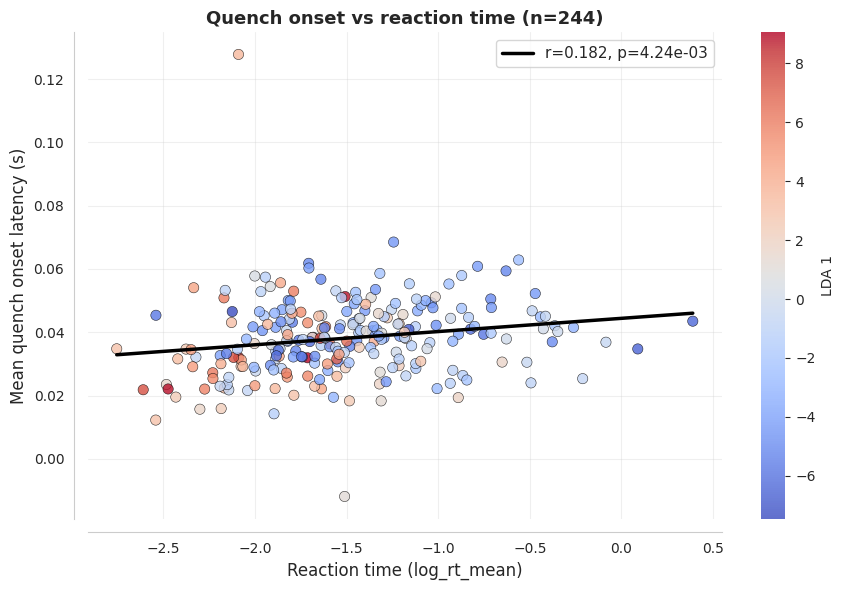

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
x = df[RT_METRIC].values; y = df['quench_onset_time'].values
sc = ax.scatter(x, y, c=df['lda_1'].values, cmap='coolwarm', alpha=0.8, s=55, edgecolors='black', linewidth=0.4)
z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
ax.plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f}, p={p:.2e}')
cb = fig.colorbar(sc, ax=ax); cb.set_label('LDA 1'); cb.outline.set_visible(False)
ax.set_xlabel(f'Reaction time ({RT_METRIC})', fontsize=12)
ax.set_ylabel('Mean quench onset latency (s)', fontsize=12)
ax.set_title(f'Quench onset vs reaction time (n={len(df)})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); sns.despine(ax=ax, offset=10)
plt.tight_layout(); plt.show()